In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from pandas.plotting import autocorrelation_plot
from statsmodels.graphics.tsaplots import plot_acf

# Loading dataset

In [4]:
import pandas as pd
df = pd.read_csv("restaurant_dataset.csv")
df

,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition
0,1/1/2024,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny
1,1/1/2024,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,False,False,Sunny
2,1/1/2024,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,False,False,Rainy
3,1/1/2024,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.8,2.04,2.48,503,False,False,Sunny
4,1/1/2024,32,Fine Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.30,55.54,262,False,False,Rainy
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1/1/2025,45,Food Stall,Cendol,Dinner,"rice flour jelly, coconut milk, palm sugar, re...",2.0,4.41,4.47,588,True,False,Sunny
9996,1/1/2025,44,Food Stall,Teh Tarik,Lunch,"black tea, condensed milk, evaporated milk",0.9,2.44,2.61,511,False,False,Rainy
9997,1/1/2025,38,Fine Dining,Iced Lemon Tea,Dinner,"black tea, lemon, sugar syrup",1.2,6.04,6.91,442,False,False,Sunny
9998,1/1/2025,3,Cafe,Cendol,Lunch,"rice flour jelly, coconut milk, palm sugar, re...",2.0,6.60,8.56,242,False,False,Sunny


# EDA

In [5]:
print("\nFirst 5 rows:")
df.head()


First 5 rows:


,date,restaurant_id,restaurant_type,menu_item_name,meal_type,key_ingredients_tags,typical_ingredient_cost,observed_market_price,actual_selling_price,quantity_sold,has_promotion,special_event,weather_condition
0,1/1/2024,11,Food Stall,Laksa,Lunch,"rice noodles, fish broth, tamarind, shrimp pas...",4.5,10.59,12.48,361,False,False,Sunny
1,1/1/2024,7,Casual Dining,Spaghetti Carbonara,Dinner,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,26.64,60.46,105,False,False,Sunny
2,1/1/2024,23,Fine Dining,Beef Rendang,Dinner,"beef, coconut milk, galangal, lemongrass, spic...",9.0,49.42,80.15,36,False,False,Rainy
3,1/1/2024,22,Food Stall,Roti Canai,Dinner,"flour, ghee, egg, water, curry",0.8,2.04,2.48,503,False,False,Sunny
4,1/1/2024,32,Fine Dining,Spaghetti Carbonara,Lunch,"spaghetti, eggs, cheese, beef bacon, black pepper",9.0,40.30,55.54,262,False,False,Rainy


In [6]:
print("\nSummary of dataset:")
df.info()

print("\nStatistics:")
df.describe()

print("\nShape:")
df.shape


Summary of dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     10000 non-null  object 
 1   restaurant_id            10000 non-null  int64  
 2   restaurant_type          10000 non-null  object 
 3   menu_item_name           10000 non-null  object 
 4   meal_type                10000 non-null  object 
 5   key_ingredients_tags     10000 non-null  object 
 6   typical_ingredient_cost  10000 non-null  float64
 7   observed_market_price    10000 non-null  float64
 8   actual_selling_price     10000 non-null  float64
 9   quantity_sold            10000 non-null  int64  
 10  has_promotion            10000 non-null  bool   
 11  special_event            10000 non-null  bool   
 12  weather_condition        10000 non-null  object 
dtypes: bool(2), float64(3), int64(2), object(6)
memory usage

(10000, 13)

In [7]:
print("\nMissing values:")
df.isnull().sum()


Missing values:


date                       0
restaurant_id              0
restaurant_type            0
menu_item_name             0
meal_type                  0
key_ingredients_tags       0
typical_ingredient_cost    0
observed_market_price      0
actual_selling_price       0
quantity_sold              0
has_promotion              0
special_event              0
weather_condition          0
dtype: int64

# Date-Time conversion

In [8]:
# Convert date column to datetime
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Remove rows with invalid dates
df = df.dropna(subset=["date"]).copy()

In [9]:
# Aggregate to daily sales
# Since this dataset has multiple rows per day, create a daily time series
daily_sales = (
    df.groupby("date", as_index=False)["quantity_sold"]
      .sum()
      .rename(columns={"quantity_sold": "daily_quantity_sold"})
)

# Sort by date
daily_sales = daily_sales.sort_values("date")

# Set datetime index
daily_sales = daily_sales.set_index("date")

print("\nDaily aggregated data:")
print(daily_sales.head())


Daily aggregated data:
            daily_quantity_sold
date                           
2024-01-01                 8479
2024-01-02                 7647
2024-01-03                 4172
2024-01-04                 7592
2024-01-05                 6712


In [10]:
# Make datetime index continuous

full_range = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

daily_sales = daily_sales.reindex(full_range)
daily_sales.index.name = "date"

print("\nMissing dates after reindexing:",
      daily_sales["daily_quantity_sold"].isna().sum())

# Fill missing dates
daily_sales["daily_quantity_sold"] = daily_sales["daily_quantity_sold"].fillna(0)

print("\nAfter filling missing dates:")
print(daily_sales.head())


Missing dates after reindexing: 0

After filling missing dates:
            daily_quantity_sold
date                           
2024-01-01                 8479
2024-01-02                 7647
2024-01-03                 4172
2024-01-04                 7592
2024-01-05                 6712


# Overall sales trend

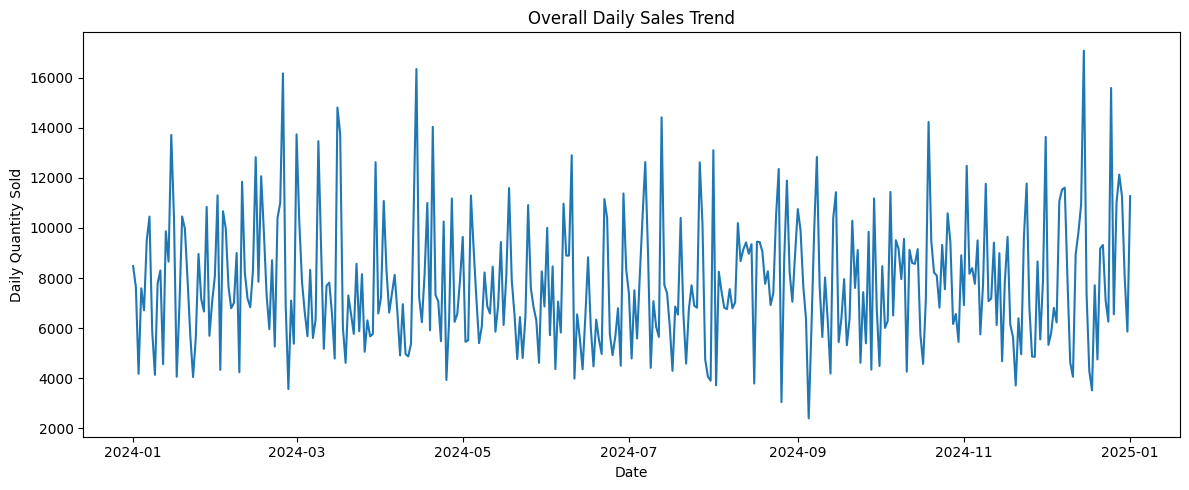

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(daily_sales.index, daily_sales["daily_quantity_sold"])
plt.title("Overall Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Daily Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


D:\Temp\ipykernel_9792\2914632922.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = daily_sales["daily_quantity_sold"].resample("M").sum()


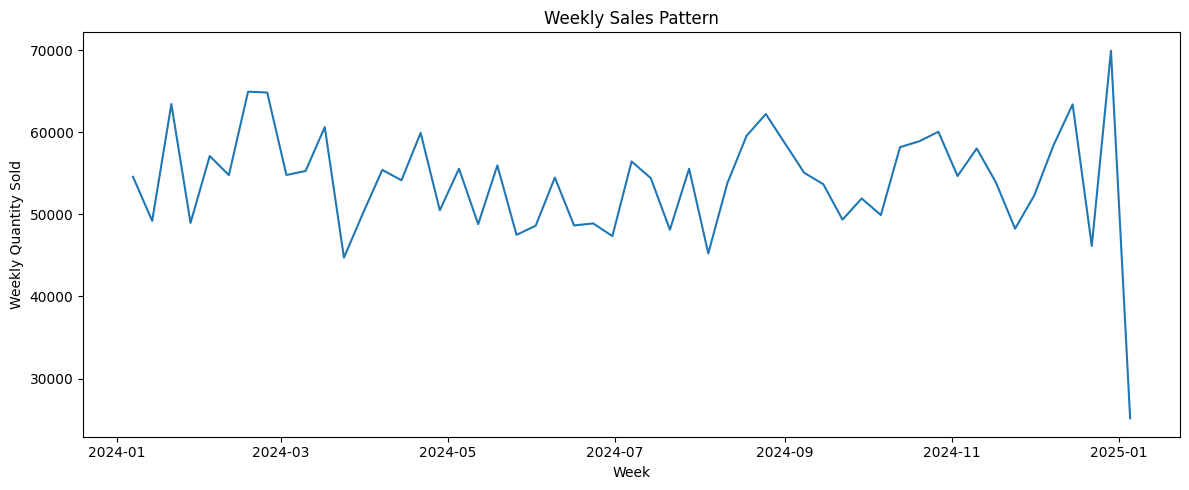

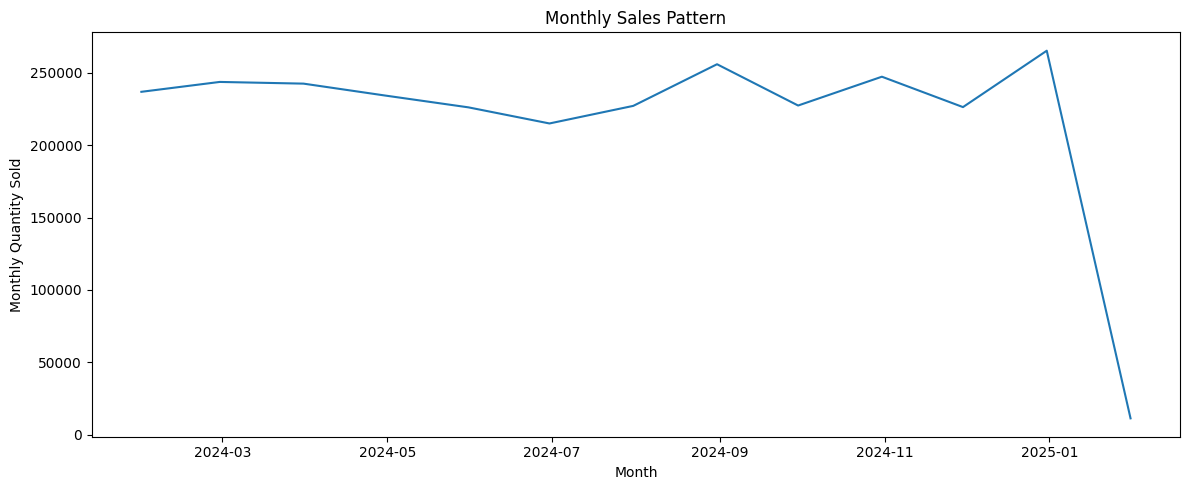

In [12]:
#  Weekly and monthly patterns

weekly_sales = daily_sales["daily_quantity_sold"].resample("W").sum()
monthly_sales = daily_sales["daily_quantity_sold"].resample("M").sum()

plt.figure(figsize=(12, 5))
plt.plot(weekly_sales.index, weekly_sales.values)
plt.title("Weekly Sales Pattern")
plt.xlabel("Week")
plt.ylabel("Weekly Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Pattern")
plt.xlabel("Month")
plt.ylabel("Monthly Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

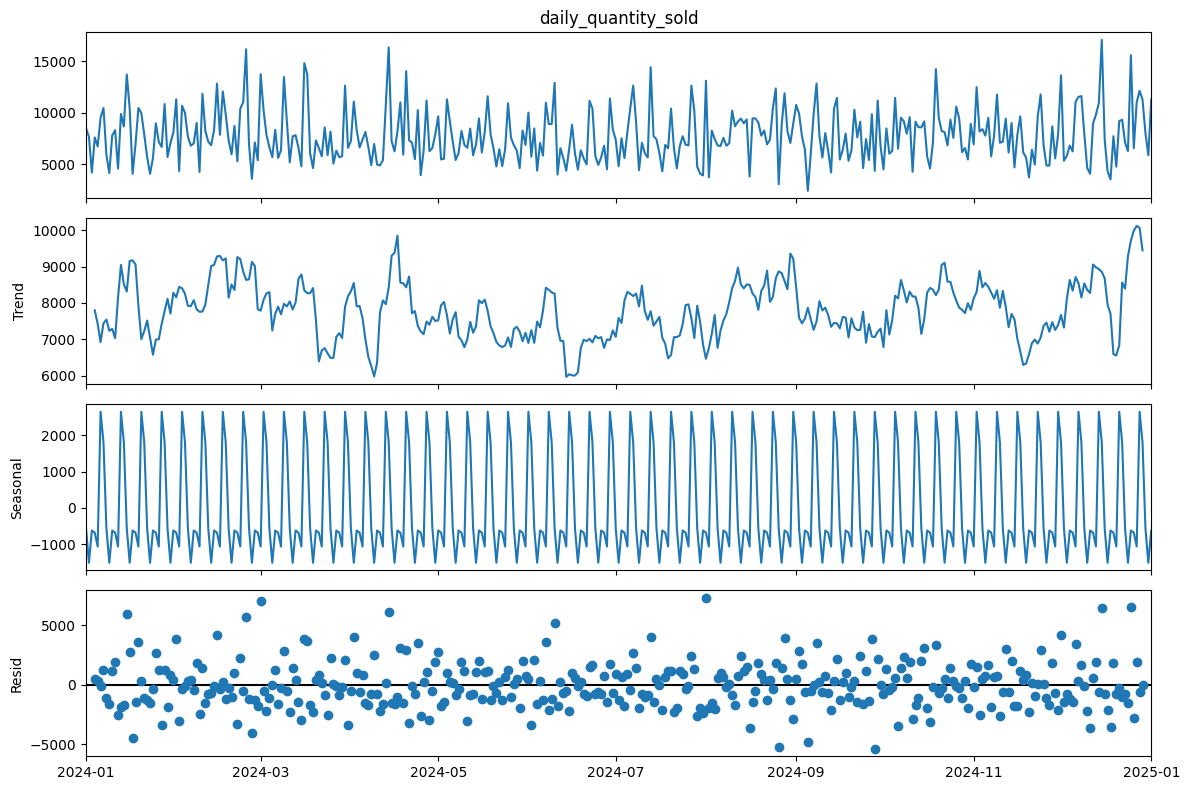

In [13]:
# Seasonal decomposition
# Weekly seasonality -> period=7 for daily data
decomposition = seasonal_decompose(
    daily_sales["daily_quantity_sold"],
    model="additive",
    period=7
)

fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

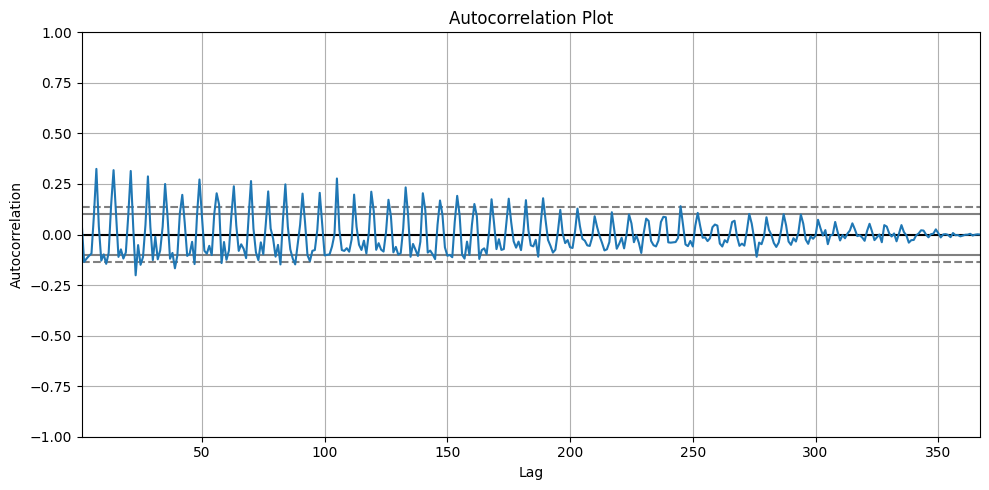

<Figure size 1000x500 with 0 Axes>

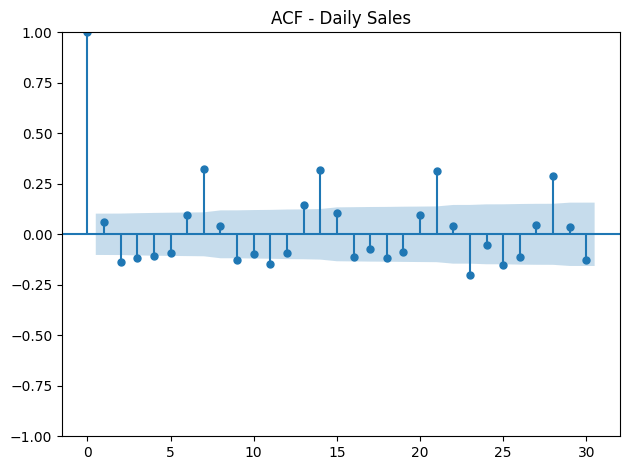

In [14]:
#  Autocorrelation analysis

plt.figure(figsize=(10, 5))
autocorrelation_plot(daily_sales["daily_quantity_sold"])
plt.title("Autocorrelation Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plot_acf(daily_sales["daily_quantity_sold"], lags=30)
plt.title("ACF - Daily Sales")
plt.tight_layout()
plt.show()